In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytest
import math
from ucimlrepo import fetch_ucirepo 


# Coisas a serem feitas:

- [ ] Validar se: A implementação deve ser generalizada para qualquer quantidade de atributos.
- [ ] **Testes Unitários:** validar individualmente métodos como `fit()`, `predict()`, funções de erro, entre outros.
- [ ] **Testes Funcionais:** validar o pipeline completo de treinamento e predição com conjuntos de dados simples.

---
#### Calibração da Taxa de Aprendizado:
* Utilizar o conjunto de desenvolvimento para encontrar a melhor taxa de aprendizado (*learning rate*).
* Após encontrar o melhor valor, retreinar o modelo utilizando o conjunto de **treinamento + desenvolvimento**, e avaliar no conjunto de **teste**.

#### Análises Obrigatórias:
* **Curva de Treinamento:**
  * Gerar um gráfico que mostre a evolução da função de erro durante o treinamento.
  * Realizar uma análise textual sobre o comportamento da curva de erro.
* **Análise dos Parâmetros:**
  * Criar um gráfico de barras exibindo os coeficientes encontrados.
  * Analisar em texto quais parâmetros são mais relevantes positiva e negativamente para a predição.

#### Avaliação Quantitativa:
* Calcular e reportar as métricas:
  * **MAE** (*Mean Absolute Error*)
  * **MSE** (*Mean Squared Error*)
  * **MAPE** (*Mean Absolute Percentage Error*)
* As métricas devem ser implementadas em módulos ou classes próprias.
* Comparar os erros de treinamento+desenvolvimento e teste.
* Analisar se há *overfitting* ou *underfitting*, justificando os resultados.

#### Análise de Tempo de Treinamento:
* Medir o tempo total de treinamento.
* Comentar sobre o desempenho temporal observado.

In [2]:
# Gerando os dados sintéticos, função y = x^2

df_sintetico = pd.DataFrame({
                'x': range(50),
                'y': [i*2 for i in range(50)]
})

In [3]:
df_sintetico.head(5)

,x,y
0,0,0
1,1,2
2,2,4
3,3,6
4,4,8


# Fórmula dos gradiente dos mínimos quadradados para múltiplos atributos:

- Função de custo
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^m (h_\theta(x^{(i)}) - y_i)^2$$

- Gradiente descedente para múltiplos atributos:

$$\theta _j := \theta _j - \alpha \frac{\partial}{\partial \theta _j} J(\theta)$$

# Como funciona

$\theta ^T$ = $\begin{bmatrix}\theta _0 & \theta _1 & \theta_2 & ... & \theta _n \end{bmatrix}_{1xn}$ 

x = $\begin{bmatrix} x_0\\ x_1  \\ ...  \\ x_n \end{bmatrix}_{nx1}$

Ou seja, cada linha corresponde a uma feature.

Onde a quantidade de colunas de j determinarão a quantidade de "predições" feitas pelo modelo, dado que a multiplicação de $\theta ^T$ * x vai ser dada por:

$ \theta ^T * x $ = $ \theta _0 * x_0 + \theta _1 * x_1 + ... + \theta _n * x_n $

- Com as dimensões de x sendo $x_{nx2}$, teríamos algo como:

$ \theta ^T * x $ = $\begin{bmatrix} \theta _0 * x_0^0 + \theta _1 * x_1^0 + ... + \theta _n * x_n^0 & \theta _0 * x_0^1 + \theta _1 * x_1^1 + ... + \theta _n * x_n^1  \end{bmatrix}_{1x2}$


In [4]:
class EvaluativeMetrics:
    # Instânciando a classe
    def __init__(self, y_pred: np.ndarray, y: np.ndarray):
        self.y_pred = y_pred
        self.y = y

    # Métrica MAE
    def MAE(self) -> float:
        """"""
        return 1/len(self.y_pred) * np.sum(abs(self.y_pred - self.y))

    # Métrica MAPE
    def MAPE(self) -> float:
        """"""
        return 100/len(self.y_pred) * np.sum((self.y_pred - self.y)/self.y)

    # Métrica MSE:
    def MSE(self) -> float:
            """"""
            return 1/len(self.y_pred) * np.sum((self.y_pred - self.y)**2)



In [5]:
def get_cyclical_lr(step, base_lr, max_lr, step_size):
    """Calcula a taxa de aprendizado usando a onda triangular"""
    ciclo = math.floor(1 + step / (2 * step_size))
    x = abs(step / step_size - 2 * ciclo + 1)
    lr = base_lr + (max_lr - base_lr) * max(0, (1 - x))
    return lr


In [ ]:
class RTrainer:
    # Etapa de treinamento, é a mais simples, implementação está no slide
    def __init__(self, base_lr, max_lr, step_size, ephocs, erro=0, logger=False, learning_teste=False):
        """Construtor da classe RTrainer"""

        self.base_lr = base_lr
        self.max_lr = max_lr
        self.step_size = step_size

        self.a = base_lr # Taxa de aprendizado
        self.ephocs = ephocs # Quantidade de iterações do modelo
        self.erro = erro # Erro mínimo, um parâmetro adicional na hora de iterar, opcional
        self.logger = logger # Um log para acompanharmos algumas coisas que possam ser interessantes de serem observadas
        self.parametros: np.ndarray
        
    def fit(self, dados_entrada_treinamento: pd.DataFrame, y_treinamento: pd.DataFrame, dados_entrada_val: pd.DataFrame, y_val: pd.DataFrame ) -> np.ndarray:
        """ Método que realiza o treinamento do modelo """

        # Facilitando a vida do usuário e transformando aqui em um numpy array
        
        dados_entrada_treinamento = dados_entrada_treinamento.to_numpy()
        y_treinamento = y_treinamento.to_numpy()
        dados_entrada_val = dados_entrada_val.to_numpy()
        y_val = y_val.to_numpy()

        # Antes de começar o treinamento, vamos primeiro modelar os dados de forma a facilitar o próprio

        x_treinamento = np.append(
                [np.ones((dados_entrada_treinamento).shape[0])], # O shape é para preencher com a quantidade de dados de entrada que temos nas outras features, esse aqui é o x0 -> vetor de 1s
                # TODO: Validar, precisei adicionar '[]' porque só temos uma coluna de entrada
                np.transpose(dados_entrada_treinamento),  # Necessário transpor porque cada linha fica como uma feature
                axis=0 # Garantindo que vamos manter uma estrutura de: cada linha é uma feature, e cada coluna é uma entrada que resulta nos dados de treinamento, que acaba sendo o contrário do que temos no slide
            )

        # Matriz de validação
        x_val = np.append(
                [np.ones((dados_entrada_val).shape[0])], 
                np.transpose(dados_entrada_val), 
                axis=0
            )
            
        # Ok, temos a matriz dos dados de entrada, agora precisamos criar os parâmetros

        self.parametros = np.ones(x_treinamento.shape[0]) # TODO: adicionar um parâmetro opcional que possa definir o tipo de inicialização desse vetor de parâmetros, se é rand, 0 e 1, vai ser um if né simples
        historico_custo = []
        historico_lr = []

        # Agora podemos realizar as predições

        for i in range(self.ephocs):

            self.a = get_cyclical_lr(step=i, base_lr=self.base_lr, max_lr=self.max_lr, step_size=self.step_size) # Usei IA nessa parte, achei meio confuso a implementação

            # Primeiro, precisamos calcular o vetor y_pred, que vai ser uma multiplicação de matrizes
            
            y_pred = self.parametros @ x_treinamento # O "@" é o operador de multiplicação de matrizes do numpy
            y_pred_val = self.parametros @ x_val

            custo = 1/(2*len(x_val[0])) * np.sum((y_pred_val - y_val)**2) 

            if custo < 0.001:
                print(i)
                break

            historico_lr.append(self.a)
            historico_custo.append(custo)
            parametros_temp = self.parametros.copy()

            # Terceiro, aplicando o método do gradiente descendente para múltiplos atributos

            for j in range(x_treinamento.shape[0]): 
                # Iterando por feature
                parametros_temp[j] = self.parametros[j] - self.a * (1/(len(x_treinamento[0]))) * np.sum((y_pred - y_treinamento) * x_treinamento[j])

            self.parametros = parametros_temp

    
        plt.figure(figsize=(8, 5))
        plt.scatter(historico_lr, historico_custo, c=range(len(historico_lr)), cmap='viridis')
        plt.xlabel('Taxa de Aprendizado (LR)')
        plt.ylabel('Custo')
        plt.title('Custo vs. Taxa de Aprendizado')
        plt.show()
        
        return self.parametros


    #  TODO: fazendo retornar um valor só, rever isso aqui
    def predict(self, dados_predicao: np.ndarray) -> float:
        """Método que realiza previsão do modelo, vai retornar -> um vetor de parâmetros OU um objeto MODEL contendo ao menos uma propriedade que indique o número de parâmetros"""

        dados_normalizados = pd.concat([pd.Series(1), dados_predicao]) # Dessa forma resolvermos a questão do theta0
        return  self.parametros @ np.transpose(dados_normalizados)
        

In [7]:
# TODO: Célula de testes


def testando_fit_modelo(modelo: RTrainer, dados_entrada: np.ndarray, y: np.ndarray):
    
    try:
        pesos = modelo.fit(dados_entrada, dados_entrada)
    except Exception as e:
        pytest.fail(f"O fit do modelo falhou por: {e}")

    # Verificação se os pesos que estão saindo do modelo estão tipados como se espera
    assert isinstance(pesos, np.ndarray)

    # Verificação da quantidade de pesos é n+1 da quantidade de colunas de entrada. Onde a quantidade de dimensões corresponde a quantidade de colunas e o shape corresponde a quatidade de parâmetros
    assert (dados_entrada.ndim + 1) == pesos.shape[0]

# TODO: Construir outras validações aqui

In [103]:
trainer = RTrainer(
    base_lr=0.001,
    max_lr=0.01,
    step_size=500,  # A cada 500 épocas a taxa atinge o pico (1 ciclo = 1000 épocas)
    ephocs=30000,
    logger=True
)
#testando_fit_modelo(testando, df_sintetico['x'].to_numpy(), df_sintetico['y'].to_numpy() )
#vetores_peso = testando.fit(df_sintetico['x'].to_numpy(), df_sintetico['y'].to_numpy()) # TODO: corrigir isso aqui para poder testar

In [43]:
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 

In [14]:
X.tail()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8


In [15]:
y.tail()

,quality
6492,6
6493,5
6494,6
6495,7
6496,6


In [64]:
def train_test_validation_split(entrada: pd.DataFrame, saida: pd.DataFrame | None = None, output: str | None = None, normalizar: bool | None = None):
    """ Função que vai fazer o embaralhamento dos dados, para garantir que não haja nenhum viés no treinamento. Além disso, separamos os dados em treinamento, validação e teste. Vamos passar um único Dataframe e vamos separar aqui dentro"""

    # TODO: se estiver a fim, da para deixar bem redondinho essa função, mas por enquanto não vou fazer
    # TODO: permitir ajustar o tamanho dos cortes

    if saida is None and output is None:
        # Ver trowexception
        return("Erro: preciso de: ou um dataframe de saída ou de uma coluna referenciando o output no dataframe de entrada")

    coluna_Y = ''
    randomizando_dataframe = ''

    # Se não tiver sido passado uma string, e sim um dataframe, vamos pegar a coluna de saída e juntar no dataframe de entrada
    if output is None:
        coluna_Y = saida.columns[0]
        randomizando_dataframe = pd.concat([entrada, saida], axis=1)
    else:
        coluna_Y = output
        randomizando_dataframe = entrada.copy()

    # Processo de "bagunçar" o dataframe
    randomizando_dataframe = randomizando_dataframe.iloc[np.random.permutation(len(randomizando_dataframe))].reset_index(drop=True) # -> Usando o numpy para rearranjar os elementos, mantendo os índices normais

    # TODO: caso for ajustar os valores do corte, é só ajustar nesses valores float aqui
    corteTeste = int(len(randomizando_dataframe)*0.70)
    corteValidacao = int(len(randomizando_dataframe)*0.90)

    parteTreinamento = randomizando_dataframe[:corteTeste] # Primeiros 70% do dataframe
    parteValidacao = randomizando_dataframe[corteTeste:corteValidacao] # Próximos 20%
    parteTeste = randomizando_dataframe[corteValidacao:] # Últimos 10%

    # Separando os três dataframes:

    colunas_X = []

    for i in randomizando_dataframe.columns:
        if i != coluna_Y:
            colunas_X.append(i)

    X_train, y_train = parteTreinamento[colunas_X].copy(), parteTreinamento[coluna_Y].copy()
    X_val, y_val = parteValidacao[colunas_X].copy(), parteValidacao[coluna_Y].copy()
    X_test, y_test = parteTeste[colunas_X].copy(),  parteTeste[coluna_Y].copy()

    if normalizar:
        for i in X_test.columns:
            X_test[i] = (X_test[i] - X_test[i].mean()) / X_test[i].std()
            X_train[i] = (X_train[i] - X_train[i].mean()) / X_train[i].std()
            X_val[i] = (X_val[i] - X_val[i].mean()) / X_val[i].std()

    return X_train, y_train, X_val, y_val, X_test, y_test


In [104]:
X_train, y_train, X_val, y_val, X_test, y_test = train_test_validation_split(X, y, normalizar=True)

18.524090510967323
18.571016490715518


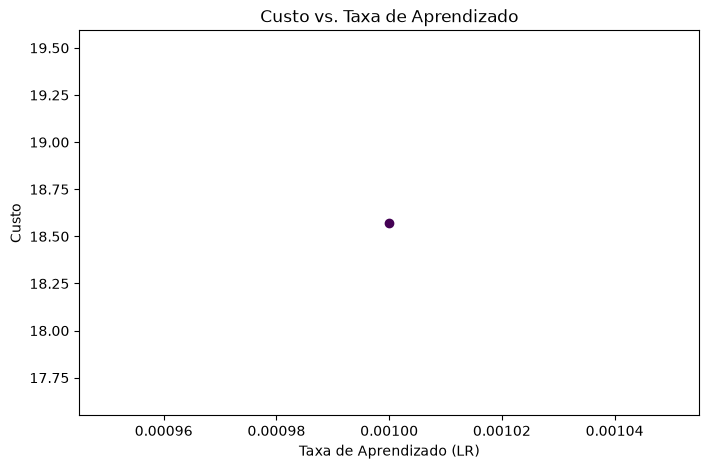

In [105]:
vetores_peso = trainer.fit(X_train, y_train, X_val, y_val)

In [89]:
print(trainer.predict(X_test.iloc[3]))
print(y_test.iloc[3])

6.071968308567211
7
